R² Score: 0.6459672901495184
Mean Squared Error: 2715546372.567625


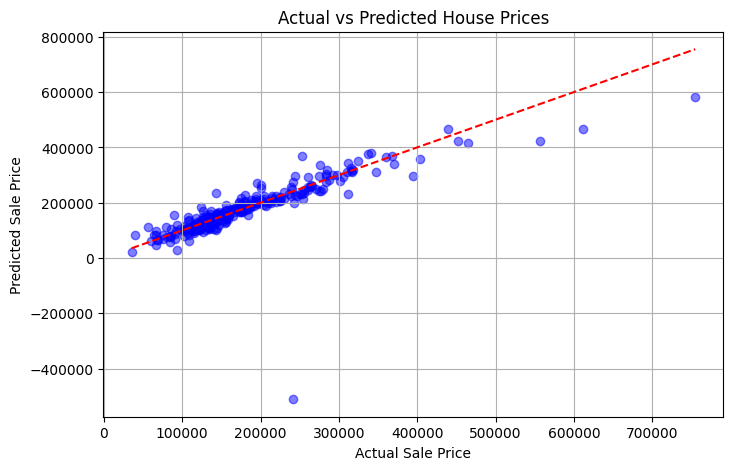

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
df = pd.read_csv("train.csv")
df.drop(columns=["Id", "Alley", "PoolQC", "MiscFeature", "FireplaceQu"],inplace=True,errors="ignore")
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df = pd.get_dummies(df, drop_first=True)
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]
X = X.astype(float)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
plt.figure(figsize=(8, 5))
plt.scatter(y_test,y_pred,alpha=0.5,color="blue")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linestyle="--")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
df = pd.read_csv("admission.csv")
df.columns = df.columns.str.strip()
print("Column names:")
print(df.columns.tolist())
df["Admitted"] = (df["Chance of Admit"] > 0.75).astype(int)
df.drop("Chance of Admit", axis=1, inplace=True)
if "Serial No." in df.columns:
    df.drop("Serial No.", axis=1, inplace=True)
X = df.drop("Admitted", axis=1)
y = df["Admitted"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("\n======================================")
print("MODEL EVALUATION")
print("======================================")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
new_student = np.array([[320, 110, 3, 4.5, 4.0, 9.61, 1]])
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)[0][1]
print("\n======================================")
print("NEW STUDENT PREDICTION")
print("======================================")
print("Admission Probability:", round(probability * 100, 2), "%")
if prediction[0] == 1:
    print("Prediction: Likely to be admitted")
else:
    print("Prediction: Unlikely to be admitted")


Column names:
['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']

MODEL EVALUATION

Confusion Matrix:
[[4 2]
 [0 4]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.67      1.00      0.80         4

    accuracy                           0.80        10
   macro avg       0.83      0.83      0.80        10
weighted avg       0.87      0.80      0.80        10

Accuracy: 0.8

NEW STUDENT PREDICTION
Admission Probability: 91.95 %
Prediction: Likely to be admitted


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Accuracy: 0.9991573329588147
ROC-AUC Score: 0.9572835078037969

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



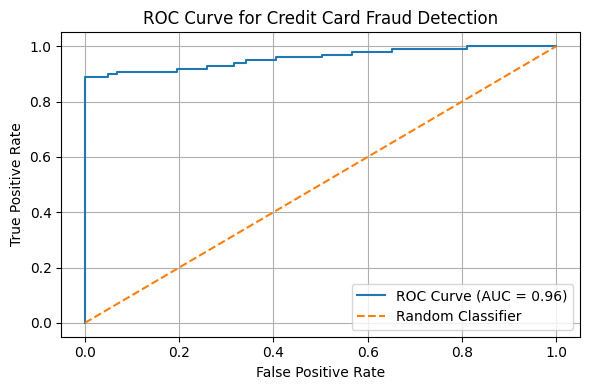

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score,roc_curve,classification_report,accuracy_score)
df = pd.read_csv("creditcard.csv")
df = df.dropna()
X = df.drop("Class", axis=1)
y = df["Class"]
scaler = StandardScaler()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
fpr, tpr, thresholds = roc_curve(y_test,y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr,tpr,label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1],[0, 1],linestyle="--",label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Credit Card Fraud Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

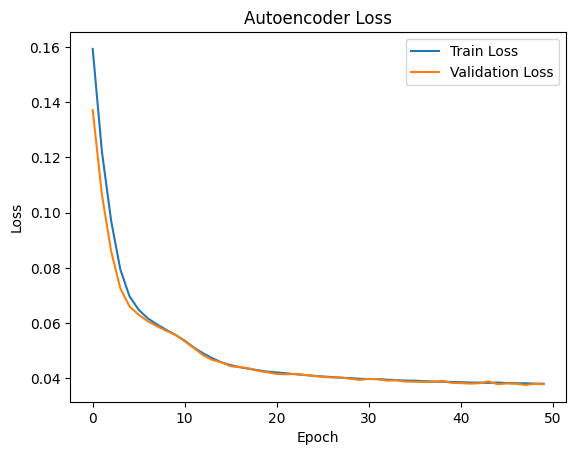

Threshold: 0.0907333443810041

Confusion Matrix:
 [[979  56]
 [359  15]]

Classification Report:
               precision    recall  f1-score   support

 Not Churned       0.73      0.95      0.83      1035
     Churned       0.21      0.04      0.07       374

    accuracy                           0.71      1409
   macro avg       0.47      0.49      0.45      1409
weighted avg       0.59      0.71      0.62      1409



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense

df=pd.read_csv("telecom churn.csv")
df.columns=df.columns.str.strip()
df.dropna(inplace=True)

y=LabelEncoder().fit_transform(df["Churn"])
X=df.drop("Churn",axis=1)

for c in X.select_dtypes("object"):
    X[c]=LabelEncoder().fit_transform(X[c].astype(str))

X=MinMaxScaler().fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

inp=Input(shape=(X_train.shape[1],))
enc=Dense(16,activation="relu")(inp)
enc=Dense(8,activation="relu")(enc)
dec=Dense(16,activation="relu")(enc)
out=Dense(X_train.shape[1],activation="sigmoid")(dec)

model=Model(inp,out)
model.compile(optimizer="adam",loss="mse")

history=model.fit(X_train,X_train,epochs=50,batch_size=32,validation_data=(X_test,X_test),verbose=0)

plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

pred=model.predict(X_test,verbose=0)
mse=np.mean((X_test-pred)**2,axis=1)
threshold=np.percentile(mse,95)
y_pred=(mse>threshold).astype(int)

print("Threshold:",threshold)
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred,target_names=["Not Churned","Churned"],zero_division=0))